# NumPy → Pandas → Matplotlib: short practical overview

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [32]:
python_list = [1, 2, 3, 4]
numpy_array = np.array([1, 2, 3, 4])

print("Python list:", python_list, type(python_list))
print("NumPy array:", numpy_array, type(numpy_array))

x = np.linspace(0, 5000, 1002)
print(x)

Python list: [1, 2, 3, 4] <class 'list'>
NumPy array: [1 2 3 4] <class 'numpy.ndarray'>
[0.00000000e+00 4.99500500e+00 9.99000999e+00 ... 4.99000999e+03
 4.99500500e+03 5.00000000e+03]


## 2. Creating arrays

A NumPy array can be one-dimensional or multi-dimensional.


In [33]:
a = np.array([1, 2, 3, 4])
b = np.array([[1, 2, 3],
              [4, 5, 6]])

print("a =", a)
print("shape of a:", a.shape)
print()
print("b =")
print(b)
print("shape of b:", b.shape)

a = [1 2 3 4]
shape of a: (4,)

b =
[[1 2 3]
 [4 5 6]]
shape of b: (2, 3)


## 3. Array properties

Two useful properties are:
- `shape` — dimensions of the array;
- `dtype` — type of its elements.


In [4]:
print("a.shape =", a.shape)
print("a.dtype =", a.dtype)
print("b.shape =", b.shape)
print("b.dtype =", b.dtype)

a.shape = (4,)
a.dtype = int64
b.shape = (2, 3)
b.dtype = int64


## 4. Indexing and slicing

Indexing works similarly to Python lists, but can be extended to multiple dimensions.


In [5]:
x = np.array([10, 20, 30, 40, 50])
y = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print("x[0] =", x[0])
print("x[1:4] =", x[1:4])
print("y[0, 2] =", y[0, 2])
print("y[:, 1] =", y[:, 1])

x[0] = 10
x[1:4] = [20 30 40]
y[0, 2] = 3
y[:, 1] = [2 5 8]


## 5. Vectorized operations

A major advantage of NumPy is that operations are applied to **all elements at once**.


In [34]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

print("u + v =", u + v)
print("u * v =", u * v)
print("u ** 2 =", u ** 2)
print("mean of v =", v.mean())

u + v = [5 7 9]
u * v = [ 4 10 18]
u ** 2 = [1 4 9]
mean of v = 5.0


### Important distinction

For one-dimensional arrays:
- `u * v` means **elementwise multiplication**;
- matrix-style operations use dedicated tools such as `@` or `np.dot(...)`.


## 6. Broadcasting

Broadcasting allows NumPy to combine arrays of different but compatible shapes.

In practice, this often means that we can add a scalar to an array, or add a row/column to a matrix.


In [35]:
arr = np.array([1, 2, 3, 4])
print("arr + 10 =", arr + 10)

M = np.array([[1, 2, 3],
              [4, 5, 6]])
row = np.array([10, 20, 30])

print()
print("M + row =")
print(M + row)

arr + 10 = [11 12 13 14]

M + row =
[[11 22 33]
 [14 25 36]]


## 7. A note on speed

NumPy is usually much faster than pure Python loops for large numerical tasks.

The exact timing depends on the machine, so here we keep the example small.


In [7]:
values_list = list(range(10_000))
values_array = np.arange(10_000)

# Same task: add 5 to every element
result_list = [x + 5 for x in values_list]
result_array = values_array + 5

print("First five elements from list result:", result_list[:5])
print("First five elements from NumPy result:", result_array[:5])

First five elements from list result: [5, 6, 7, 8, 9]
First five elements from NumPy result: [5 6 7 8 9]


# 8. Linear algebra with NumPy

NumPy is also convenient for basic linear algebra.

For teaching purposes, it is useful to clearly separate:

- **elementwise multiplication**: `A * B`
- **matrix multiplication**: `A @ B`


In [36]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A =")
print(A)
print()
print("B =")
print(B)

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]


In [37]:
print("Elementwise multiplication A * B:")
print(A * B)

print()
print("Matrix multiplication A @ B:")
print(A @ B)

Elementwise multiplication A * B:
[[ 5 12]
 [21 32]]

Matrix multiplication A @ B:
[[19 22]
 [43 50]]


## 9. Transpose, dot product, inverse

These operations appear often in physics, engineering, and machine learning.


In [10]:
vector_1 = np.array([1, 2, 3])
vector_2 = np.array([4, 5, 6])

print("Dot product:", np.dot(vector_1, vector_2))
print()
print("Transpose of A:")
print(A.T)
print()
print("Determinant of A:", np.linalg.det(A))
print("Inverse of A:")
print(np.linalg.inv(A))

Dot product: 32

Transpose of A:
[[1 3]
 [2 4]]

Determinant of A: -2.0000000000000004
Inverse of A:
[[-2.   1. ]
 [ 1.5 -0.5]]


## 10. Small practical example

Suppose the rows of a matrix represent observations, and the columns represent features.
Then linear algebra operations let us transform or combine data compactly.


In [38]:
X = np.array([[1.0, 2.0],
              [2.0, 1.0],
              [3.0, 4.0]])

w = np.array([0.5, 1.5])

prediction = X @ w
print("X =")
print(X)
print()
print("w =", w)
print("X @ w =", prediction)

X =
[[1. 2.]
 [2. 1.]
 [3. 4.]]

w = [0.5 1.5]
X @ w = [3.5 2.5 7.5]


# 11. From arrays to tables: Pandas

NumPy is excellent for numerical arrays, but real-world data usually comes with:

- column names,
- row labels,
- mixed data types,
- missing values,
- filtering and grouping tasks.

This is where **Pandas** is useful.


## 12. Series and DataFrame

Two core Pandas objects are:

- `Series` — similar to one labeled column;
- `DataFrame` — a full table with rows and columns.


In [39]:
months = pd.Series(
    ["January", "February", "March", "April"],
    index=["first", "second", "third", "fourth"]
)

print(months)
print()
print("months['first'] =", months["first"])

first      January
second    February
third        March
fourth       April
dtype: str

months['first'] = January


In [40]:
students = pd.DataFrame({
    "name": ["Anna", "Boris", "Clara", "David"],
    "age": [20, 21, 19, 22],
    "score": [85, 91, 78, 88]
})

students

,name,age,score
0,Anna,20,85
1,Boris,21,91
2,Clara,19,78
3,David,22,88


## 13. Inspecting a table

The most common first steps are:

- `head()` — first rows,
- `shape` — size of the table,
- `info()` — basic structure,
- `describe()` — summary statistics for numeric columns.


In [ ]:
students.head()

,name,age,score
0,Anna,20,85
1,Boris,21,91
2,Clara,19,78
3,David,22,88


In [52]:
feaches = ["age", "score"]
students[feaches]

,age,score
0,20,85
1,21,91
2,19,78
3,22,88


In [43]:
print("Shape:", students.shape)
students.info()

Shape: (4, 3)
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    4 non-null      str  
 1   age     4 non-null      int64
 2   score   4 non-null      int64
dtypes: int64(2), str(1)
memory usage: 228.0 bytes


In [44]:
students.describe()

,age,score
count,4.000000,4.000000
mean,20.500000,85.500000
std,1.290994,5.567764
min,19.000000,78.000000
25%,19.750000,83.250000
50%,20.500000,86.500000
75%,21.250000,88.750000
max,22.000000,91.000000


## 14. Selecting columns and rows

Pandas makes it easy to work with specific parts of a table.


In [47]:
print("One column:")
print(students["score"])
print()
print("Several columns:")
print(type(students[["name", "score"]]))

One column:
0    85
1    91
2    78
3    88
Name: score, dtype: int64

Several columns:
<class 'pandas.DataFrame'>


In [17]:
print("Row with index 1 via iloc:")
print(students.iloc[1])
print()
print("Rows with score > 80:")
students[students["score"] > 80]

Row with index 1 via iloc:
name     Boris
age         21
score       91
Name: 1, dtype: object

Rows with score > 80:


,name,age,score
0,Anna,20,85
1,Boris,21,91
3,David,22,88


## 15. Simple statistics

Once the data is in a DataFrame, simple descriptive analysis becomes easy.


In [53]:
print("Mean score:", students["score"].mean())
print("Maximum score:", students["score"].max())
print("Minimum age:", students["age"].min())

Mean score: 85.5
Maximum score: 91
Minimum age: 19


## 16. Reading data from a local CSV file

Instead of loading a table from a website, this lesson uses a **local CSV file**.

A small demo dataset has been prepared and saved next to this notebook as:

`restaurant_demo.csv`

It contains restaurant-style tabular data:
- `total_bill`
- `tip`
- `sex`
- `smoker`
- `day`
- `time`
- `size`


In [54]:
df = pd.read_csv("restaurant_demo.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,9.81,1.00,Male,No,Fri,Lunch,2
1,17.66,1.00,Male,No,Sun,Dinner,3
2,20.49,4.33,Female,No,Sat,Dinner,2
3,23.52,3.65,Male,Yes,Sat,Lunch,3
4,27.57,3.22,Female,No,Thu,Lunch,6


In [55]:
print("Shape:", df.shape)
df.info()

Shape: (80, 7)
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  80 non-null     float64
 1   tip         80 non-null     float64
 2   sex         80 non-null     str    
 3   smoker      80 non-null     str    
 4   day         80 non-null     str    
 5   time        80 non-null     str    
 6   size        80 non-null     int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 4.5 KB


## 17. Filtering real table data

Now we can ask simple questions about the table.


In [56]:
print("Average total bill:", round(df["total_bill"].mean(), 2))
print("Average tip:", round(df["tip"].mean(), 2))

Average total bill: 24.96
Average tip: 2.87


In [59]:
print("Dinner only:")
df[df["size"] > 2]["tip"].mean()

Dinner only:


np.float64(3.017857142857143)

In [22]:
print("Tables with total bill above 25:")
df[df["total_bill"] > 25].head()

Tables with total bill above 25:


,total_bill,tip,sex,smoker,day,time,size
4,27.57,3.22,Female,No,Thu,Lunch,6
5,29.65,5.39,Male,Yes,Thu,Dinner,2
6,30.85,3.73,Female,No,Thu,Lunch,6
7,29.74,2.50,Male,No,Sun,Dinner,5
12,25.74,1.98,Female,No,Sun,Dinner,2


In [60]:
print("Average total bill by day:")
df.groupby("day")["total_bill"].mean().sort_values()

Average total bill by day:


day
Fri    21.073333
Thu    22.920833
Sun    25.683000
Sat    29.363333
Name: total_bill, dtype: float64

# 18. Why visualization matters

Tables are useful, but patterns are often easier to understand from a plot.

Matplotlib is a basic plotting library in Python and works well together with both NumPy and Pandas.


## 19. A simple line plot

A line plot is useful when values are ordered, for example by time or by index.


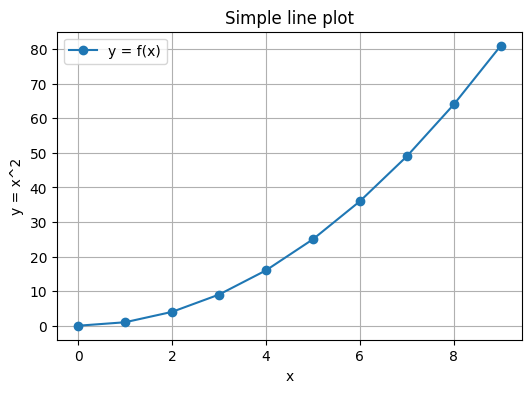

In [63]:
x = np.arange(0, 10, 1)
y = x**2

plt.figure(figsize=(6, 4))
plt.plot(x, y, marker="o", label="y = f(x)")
plt.title("Simple line plot")
plt.xlabel("x")
plt.ylabel("y = x^2")
plt.grid(True)
plt.legend()
plt.show()

## 20. Histogram

A histogram shows the distribution of a numeric variable.


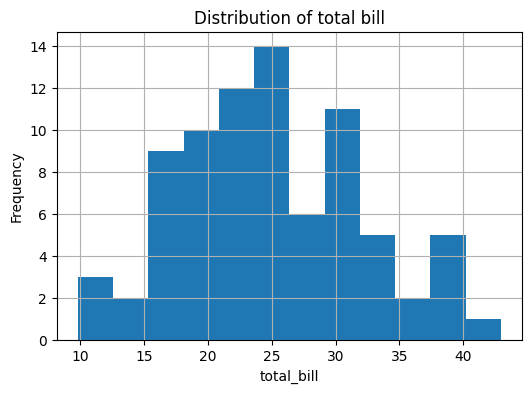

In [25]:
plt.figure(figsize=(6, 4))
df["total_bill"].hist(bins=12)
plt.title("Distribution of total bill")
plt.xlabel("total_bill")
plt.ylabel("Frequency")
plt.show()

## 21. Scatter plot

A scatter plot helps us inspect the relationship between two numeric variables.


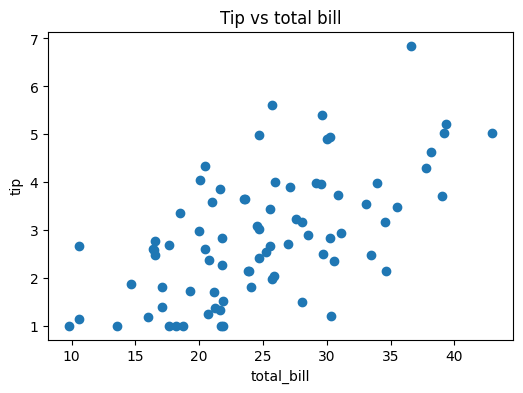

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(df["total_bill"], df["tip"])
plt.title("Tip vs total bill")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()

## 22. Bar plot from grouped data

We can first aggregate with Pandas and then visualize the result with Matplotlib.


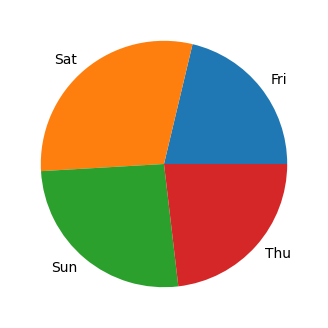

In [64]:
avg_bill_by_day = df.groupby("day")["total_bill"].mean()

plt.figure(figsize=(6, 4))
avg_bill_by_day.plot(kind="pie")
plt.show()

# 23. Full mini-workflow

Now let us combine all three libraries in one short example:

1. generate numeric data with NumPy;
2. put it into a Pandas DataFrame;
3. compute a statistic;
4. visualize the result with Matplotlib.


Mean value: 10.121
Standard deviation: 1.779


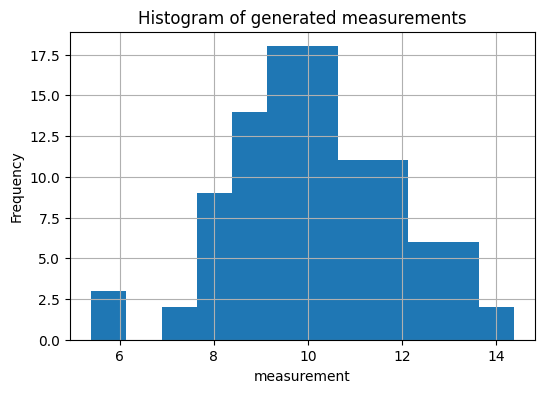

In [28]:
np.random.seed(1)

measurements = np.random.normal(loc=10, scale=2, size=100)
data = pd.DataFrame({"measurement": measurements})

print("Mean value:", round(data["measurement"].mean(), 3))
print("Standard deviation:", round(data["measurement"].std(), 3))

plt.figure(figsize=(6, 4))
data["measurement"].hist(bins=12)
plt.title("Histogram of generated measurements")
plt.xlabel("measurement")
plt.ylabel("Frequency")
plt.show()